# Tracer l'évolution de la masse monétaire mondiale

## Objectif : prouver que la tendance est haussière à long terme

In [19]:
KEY = "3743341701629489cd1c5ef73f8c6db3"

✓ API OK : États-Unis (M2)


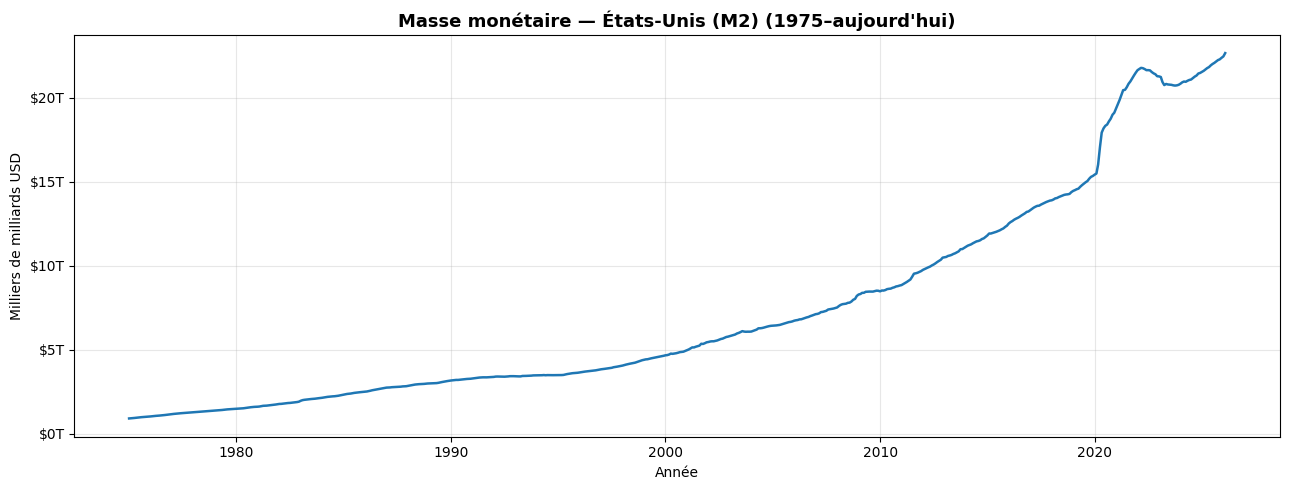

✓ Sauvegardé : C:\Users\aleor\Desktop\Ecole\Centrale_Lille\Défi G1G2\GitHub\Defi_G1G2\Plots\masse_monetaire_usa.png
✓ API OK : Zone Euro (M3)


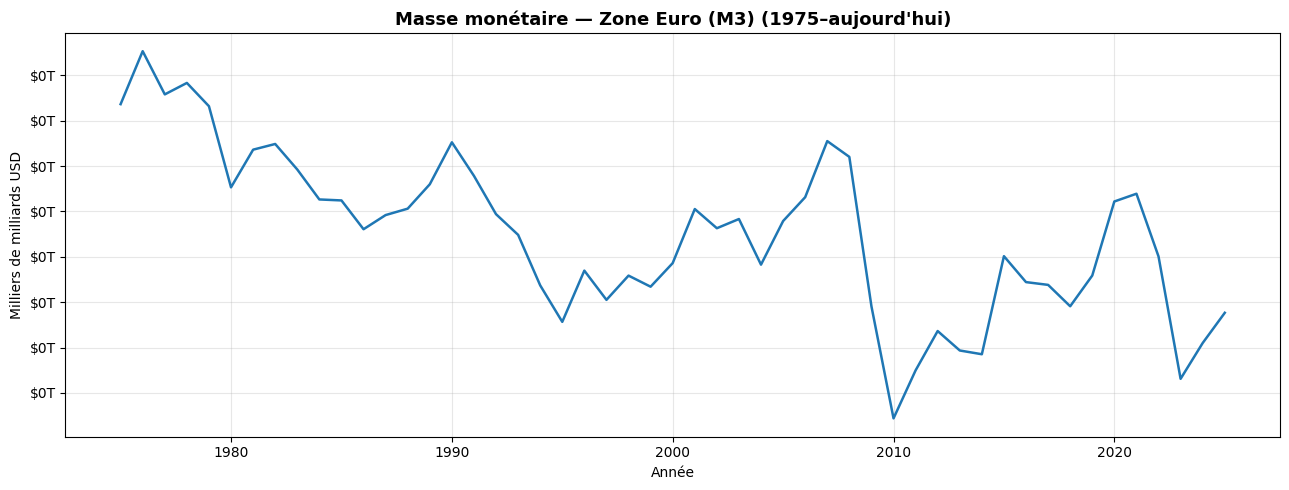

✓ Sauvegardé : C:\Users\aleor\Desktop\Ecole\Centrale_Lille\Défi G1G2\GitHub\Defi_G1G2\Plots\masse_monetaire_europe.png
✓ API OK : Chine (M2)


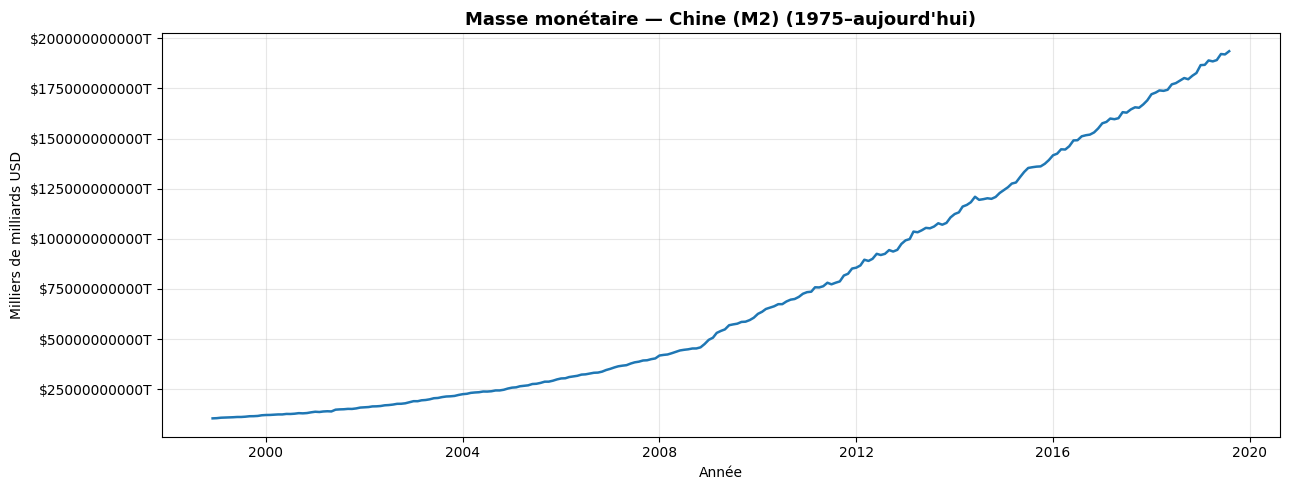

✓ Sauvegardé : C:\Users\aleor\Desktop\Ecole\Centrale_Lille\Défi G1G2\GitHub\Defi_G1G2\Plots\masse_monetaire_chine.png


In [20]:
import requests, pandas as pd, matplotlib.pyplot as plt, os
from io import StringIO

desktop = os.path.join(os.path.expanduser("~"), "Desktop\Ecole\Centrale_Lille\Défi G1G2\GitHub\Defi_G1G2\Plots")

series = {
    "États-Unis (M2)": ("M2SL",            os.path.join(desktop, "masse_monetaire_usa.png")),
    "Zone Euro (M3)":  ("MABMM301EZA657S", os.path.join(desktop, "masse_monetaire_europe.png")),
    "Chine (M2)":      ("MYAGM2CNM189N",   os.path.join(desktop, "masse_monetaire_chine.png")),
}

# Fallback FRED direct CSV (contourne l'API instable)
def fetch_fred_csv(series_id):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers, timeout=15)
    df = pd.read_csv(StringIO(r.text), parse_dates=["DATE"], index_col="DATE")
    df.columns = ["value"]
    df["value"] = pd.to_numeric(df["value"], errors="coerce") / 1000
    return df.dropna()

# API FRED JSON classique
def fetch_fred_api(series_id, key):
    url = (
        f"https://api.stlouisfed.org/fred/series/observations"
        f"?series_id={series_id}&observation_start=1975-01-01"
        f"&file_type=json&api_key={key}"
    )
    data = requests.get(url, timeout=15).json()
    if "observations" not in data:
        raise ValueError(data.get("error_message", "Unknown error"))
    df = pd.DataFrame(data["observations"])
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce") / 1000
    return df.set_index("date").dropna()

series = {
    "États-Unis (M2)": ("M2SL",            os.path.join(desktop, "masse_monetaire_usa.png")),
    "Zone Euro (M3)":  ("MABMM301EZA657S", os.path.join(desktop, "masse_monetaire_europe.png")),
    "Chine (M2)":      ("MYAGM2CNM189N",   os.path.join(desktop, "masse_monetaire_chine.png")),
}

for label, (series_id, filename) in series.items():
    try:
        df = fetch_fred_api(series_id, KEY)
        print(f"✓ API OK : {label}")
    except Exception as e:
        print(f"⚠ API échouée ({e}), fallback CSV pour {label}...")
        try:
            df = fetch_fred_csv(series_id)
        except Exception as e2:
            print(f"✗ Échec total pour {label}: {e2}")
            continue

    df = df[df.index >= "1975-01-01"]

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(df.index, df["value"], linewidth=1.8, color="#1f77b4")
    ax.set_title(f"Masse monétaire — {label} (1975–aujourd'hui)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Milliers de milliards USD")
    ax.set_xlabel("Année")
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}T"))
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    plt.close()
    print(f"✓ Sauvegardé : {filename}")

✓ API OK : États-Unis (M2)


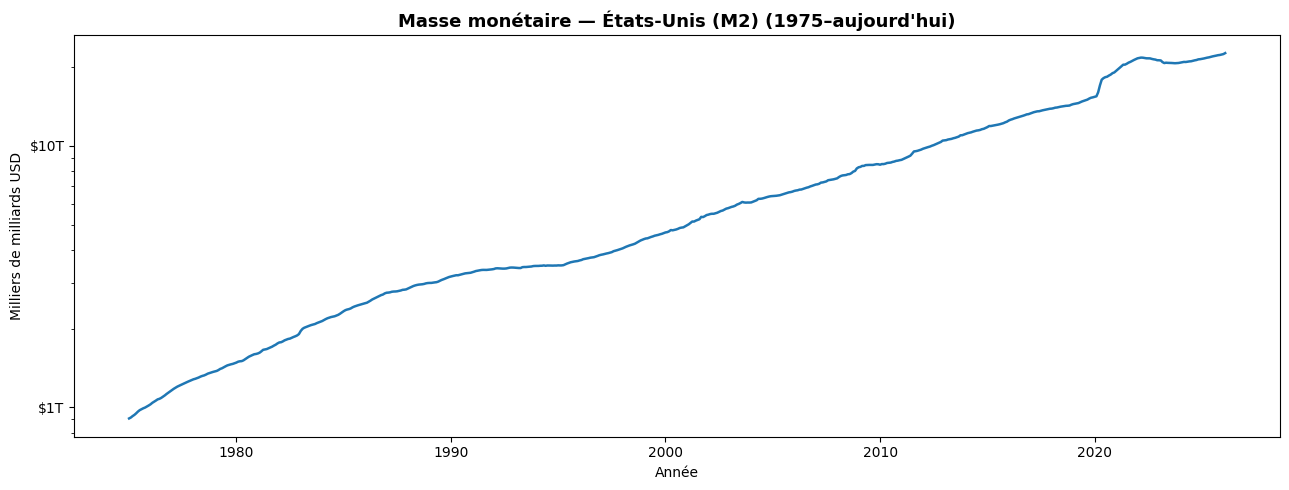

✓ Sauvegardé : C:\Users\aleor\Desktop\Ecole\Centrale_Lille\Défi G1G2\GitHub\Defi_G1G2\Plots\masse_monetaire_usa_log.png
✓ API OK : Zone Euro (M3)


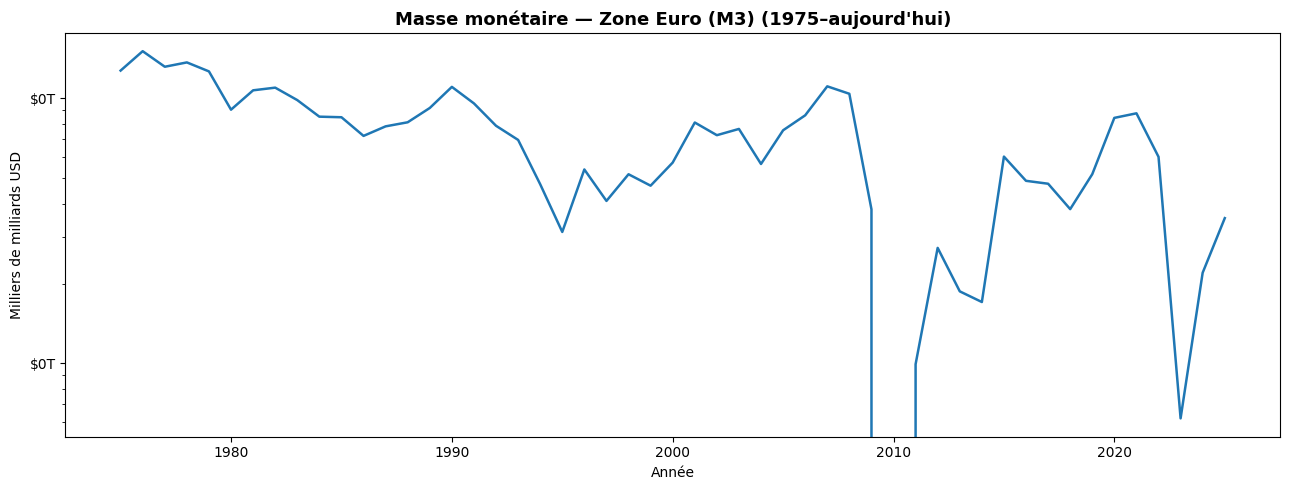

✓ Sauvegardé : C:\Users\aleor\Desktop\Ecole\Centrale_Lille\Défi G1G2\GitHub\Defi_G1G2\Plots\masse_monetaire_europe_log.png
✓ API OK : Chine (M2)


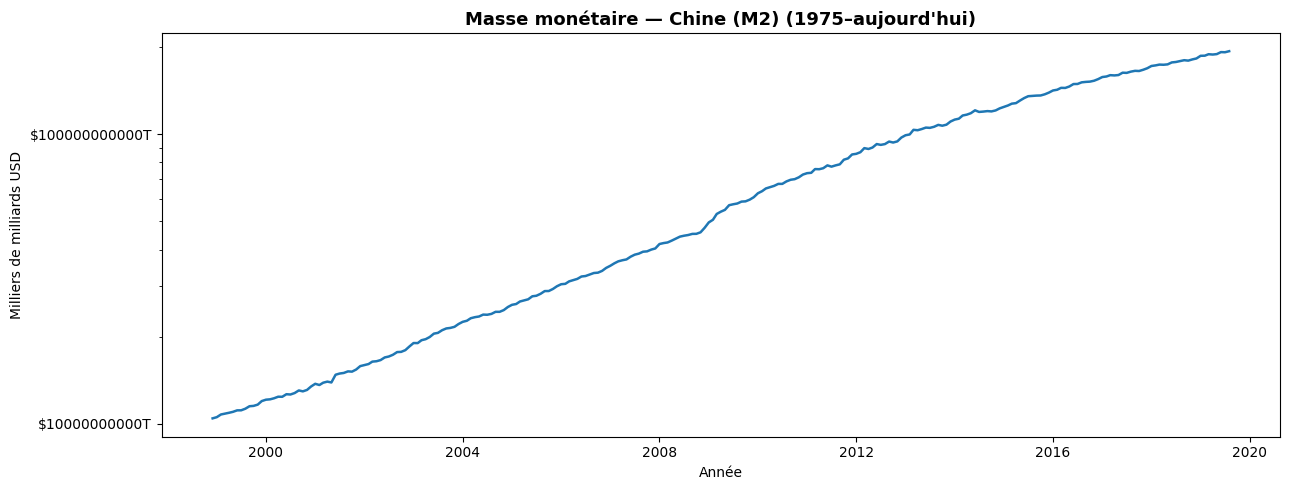

✓ Sauvegardé : C:\Users\aleor\Desktop\Ecole\Centrale_Lille\Défi G1G2\GitHub\Defi_G1G2\Plots\masse_monetaire_chine_log.png


In [21]:
import requests, pandas as pd, matplotlib.pyplot as plt, os
from io import StringIO

desktop = os.path.join(os.path.expanduser("~"), "Desktop\Ecole\Centrale_Lille\Défi G1G2\GitHub\Defi_G1G2\Plots")

series = {
    "États-Unis (M2)": ("M2SL",            os.path.join(desktop, "masse_monetaire_usa.png")),
    "Zone Euro (M3)":  ("MABMM301EZA657S", os.path.join(desktop, "masse_monetaire_europe.png")),
    "Chine (M2)":      ("MYAGM2CNM189N",   os.path.join(desktop, "masse_monetaire_chine.png")),
}

# Fallback FRED direct CSV (contourne l'API instable)
def fetch_fred_csv(series_id):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers, timeout=15)
    df = pd.read_csv(StringIO(r.text), parse_dates=["DATE"], index_col="DATE")
    df.columns = ["value"]
    df["value"] = pd.to_numeric(df["value"], errors="coerce") / 1000
    return df.dropna()

# API FRED JSON classique
def fetch_fred_api(series_id, key):
    url = (
        f"https://api.stlouisfed.org/fred/series/observations"
        f"?series_id={series_id}&observation_start=1975-01-01"
        f"&file_type=json&api_key={key}"
    )
    data = requests.get(url, timeout=15).json()
    if "observations" not in data:
        raise ValueError(data.get("error_message", "Unknown error"))
    df = pd.DataFrame(data["observations"])
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce") / 1000
    return df.set_index("date").dropna()

series = {
    "États-Unis (M2)": ("M2SL",            os.path.join(desktop, "masse_monetaire_usa_log.png")),
    "Zone Euro (M3)":  ("MABMM301EZA657S", os.path.join(desktop, "masse_monetaire_europe_log.png")),
    "Chine (M2)":      ("MYAGM2CNM189N",   os.path.join(desktop, "masse_monetaire_chine_log.png")),
}

for label, (series_id, filename) in series.items():
    try:
        df = fetch_fred_api(series_id, KEY)
        print(f"✓ API OK : {label}")
    except Exception as e:
        print(f"⚠ API échouée ({e}), fallback CSV pour {label}...")
        try:
            df = fetch_fred_csv(series_id)
        except Exception as e2:
            print(f"✗ Échec total pour {label}: {e2}")
            continue

    df = df[df.index >= "1975-01-01"]

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(df.index, df["value"], linewidth=1.8, color="#1f77b4")
    ax.set_title(f"Masse monétaire — {label} (1975–aujourd'hui)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Milliers de milliards USD")
    ax.set_xlabel("Année")
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}T"))
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    plt.close()
    print(f"✓ Sauvegardé : {filename}")